# CZ Benchmarks: Foundation Models Only Evaluation

This notebook evaluates scGPT and Transcriptformer alone (without GenePT) using CZ's label prediction task for direct comparison with our combined results.

Based on precomputed embeddings from Phase 1 (scGPT and Transcriptformer generation).

In [8]:
# Setup notebook environment
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path

# Add parent directory to path
repo_dir = Path.cwd().parent
if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

print(f"Repository directory: {repo_dir}")
data_dir = repo_dir / "data"
print(f"Data directory: {data_dir}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repository directory: /Users/rj/personal/GenePT-tools
Data directory: /Users/rj/personal/GenePT-tools/data


In [9]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from pathlib import Path
from tqdm.auto import tqdm
from dataclasses import dataclass, field
from typing import List, Dict
import warnings
warnings.filterwarnings('ignore')

# CZ Benchmarks imports
from czbenchmarks.tasks.label_prediction import MetadataLabelPredictionTask

print("✓ All imports successful")

✓ All imports successful


## Configuration

In [10]:
@dataclass
class CZBenchmarkConfig:
    """Configuration for CZ benchmarks evaluation"""
    tissue_types: List[str] = field(default_factory=lambda: [
        'Blood', 'Bone_Marrow', 'Lung', 'Mammary', 'Thymus'
    ])
    # Only evaluate foundation models alone (no GenePT combinations)
    embedding_combinations: List[str] = field(default_factory=lambda: [
        'scgpt',
        'transcriptformer'
    ])
    cv_folds: int = 5
    min_class_size: int = 10
    random_seed: int = 42
    
    # Paths
    benchmark_data_dir: Path = Path("/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark")
    embedding_dir: Path = data_dir / 'cz_benchmark' / 'embeddings'  # Base directory, not 'combined'
    results_dir: Path = data_dir / 'cz_benchmark' / 'results'

config = CZBenchmarkConfig()
config.results_dir.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Tissues: {config.tissue_types}")
print(f"  Embeddings: {config.embedding_combinations}")
print(f"  CV folds: {config.cv_folds}")
print(f"  Results dir: {config.results_dir}")

Configuration:
  Tissues: ['Blood', 'Bone_Marrow', 'Lung', 'Mammary', 'Thymus']
  Embeddings: ['scgpt', 'transcriptformer']
  CV folds: 5
  Results dir: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results


## Data Loading Functions

In [11]:
def load_tabula_sapiens_dataset(tissue_name: str, config: CZBenchmarkConfig) -> ad.AnnData:
    """Load Tabula Sapiens v2 curated dataset."""
    # Files are named: homo_sapiens_{uuid}_{tissue}_v2_curated.h5ad
    pattern = f"*_{tissue_name}_v2_curated.h5ad"
    files = list(config.benchmark_data_dir.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No h5ad file found for tissue: {tissue_name}")
    
    file_path = files[0]
    print(f"Loading {tissue_name} from: {file_path.name}")
    
    adata = sc.read_h5ad(file_path)
    
    # Handle layers - Tabula Sapiens v2 stores data in X_original layer
    if adata.X is None or (hasattr(adata.X, 'nnz') and adata.X.nnz == 0):
        if 'X_original' in adata.layers:
            adata.X = adata.layers['X_original'].copy()
        else:
            raise ValueError(f"No expression data found in adata.X or adata.layers['X_original']")
    
    # Ensure cell_type column exists
    if 'cell_type' not in adata.obs.columns:
        for col in ['cell_ontology_class', 'celltype', 'CellType', 'free_annotation']:
            if col in adata.obs.columns:
                adata.obs['cell_type'] = adata.obs[col]
                print(f"Using column '{col}' as cell_type")
                break
    
    print(f"  Loaded: {adata.n_obs} cells, {adata.n_vars} genes, {adata.obs['cell_type'].nunique()} cell types")
    
    return adata

def load_foundation_model_embeddings(tissue_name: str, embedding_name: str, adata: ad.AnnData, config: CZBenchmarkConfig) -> np.ndarray:
    """
    Load foundation model embeddings (scGPT or Transcriptformer alone).
    
    For scGPT: Has cell_id column, so we align by cell IDs.
    For Transcriptformer: No cell_id, assumes same order as adata.
    """
    
    # Determine subdirectory and file naming based on model
    if embedding_name == 'scgpt':
        embedding_path = config.embedding_dir / 'scgpt' / f'scgpt_{tissue_name}_embeddings.parquet'
        prefix = 'embedding_'
        has_cell_ids = True
    elif embedding_name == 'transcriptformer':
        embedding_path = config.embedding_dir / 'transcriptformer' / f'transcriptformer_tf_metazoa_{tissue_name}_embeddings.parquet'
        prefix = 'emb_'
        has_cell_ids = False  # Transcriptformer assumes same order as adata
    else:
        raise ValueError(f"Unknown embedding type: {embedding_name}")
    
    if not embedding_path.exists():
        raise FileNotFoundError(f"Embedding file not found: {embedding_path}")
    
    df = pd.read_parquet(embedding_path)
    
    # Extract embedding columns
    emb_cols = [col for col in df.columns if col.startswith(prefix)]
    embeddings = df[emb_cols].values
    
    # Handle alignment
    if has_cell_ids:
        # scGPT has cell_id column - align by cell IDs
        cell_ids = df['cell_id'].values
        adata_cell_ids = adata.obs_names.values
        
        # Check if alignment is needed
        if not np.array_equal(cell_ids, adata_cell_ids):
            print(f"  Aligning {embedding_name} by cell IDs...")
            # Create mapping from cell_id to row index
            cell_id_to_idx = {cid: idx for idx, cid in enumerate(cell_ids)}
            # Reorder embeddings to match adata
            aligned_indices = [cell_id_to_idx[cid] for cid in adata_cell_ids if cid in cell_id_to_idx]
            embeddings = embeddings[aligned_indices]
            print(f"  Aligned to {len(aligned_indices)} cells")
    else:
        # Transcriptformer assumes same order as adata - just verify shape
        if embeddings.shape[0] != adata.n_obs:
            raise ValueError(f"Shape mismatch: {embedding_name} has {embeddings.shape[0]} cells but adata has {adata.n_obs} cells")
        print(f"  Using {embedding_name} in original order (assumes same order as adata)")
    
    print(f"  Loaded {embedding_name}: {embeddings.shape}")
    
    return embeddings

## CZ Label Prediction Task Wrapper

In [12]:
def run_cz_label_prediction(embeddings: np.ndarray, adata: ad.AnnData, config: CZBenchmarkConfig) -> Dict:
    """
    Run CZ label prediction task with standardized parameters.
    
    Args:
        embeddings: Cell embeddings as numpy array (n_cells, n_dims)
        adata: AnnData object with cell_type labels in obs
        config: Benchmark configuration
    
    Returns:
        Dict with metrics from CZ benchmarks task
    """
    from czbenchmarks.tasks.label_prediction import MetadataLabelPredictionTaskInput
    
    print(f"  Running CZ label prediction task...")
    print(f"    Embeddings: {embeddings.shape}")
    print(f"    Labels: {adata.n_obs} cells, {adata.obs['cell_type'].nunique()} cell types")
    
    # Initialize task (only takes random_seed)
    task = MetadataLabelPredictionTask(random_seed=config.random_seed)
    
    # Convert labels to numpy array (handle pandas Categorical)
    labels = np.asarray(adata.obs['cell_type'])
    
    # Create task input with n_folds and min_class_size
    task_input = MetadataLabelPredictionTaskInput(
        labels=labels,
        n_folds=config.cv_folds,
        min_class_size=config.min_class_size
    )
    
    # Run task with embeddings and task_input
    results = task.run(
        cell_representation=embeddings,
        task_input=task_input
    )
    
    print(f"    ✓ Task complete - {len(results)} metrics returned")
    
    return results

## Evaluation Pipeline

In [13]:
def evaluate_tissue_embedding_combination(
    tissue_name: str,
    embedding_name: str,
    config: CZBenchmarkConfig
) -> Dict:
    """
    Evaluate a single tissue-embedding combination.
    """
    print(f"\n{'='*80}")
    print(f"Tissue: {tissue_name} | Embedding: {embedding_name}")
    print('='*80)
    
    try:
        # Load AnnData for labels
        adata = load_tabula_sapiens_dataset(tissue_name, config)
        
        # Load embeddings (pass adata for alignment/verification)
        embeddings = load_foundation_model_embeddings(tissue_name, embedding_name, adata, config)
        
        # Run CZ label prediction
        results = run_cz_label_prediction(embeddings, adata, config)
        
        # Parse results - CZ returns list of MetricResult objects
        result_dict = {
            'tissue': tissue_name,
            'embedding': embedding_name,
            'n_cells': adata.n_obs,
            'n_cell_types': adata.obs['cell_type'].nunique(),
            'embedding_dims': embeddings.shape[1],
            'status': 'success'
        }
        
        # Extract metrics from CZ results (list of MetricResult objects)
        for metric_result in results:
            metric_name = str(metric_result.metric_type.value)
            metric_value = metric_result.value
            classifier = metric_result.params.get('classifier', 'unknown')
            
            # Create column name with classifier info
            col_name = f"{metric_name}_{classifier}"
            result_dict[col_name] = metric_value
            
            # Also save the main mean metrics without classifier suffix for easier access
            if 'MEAN(' in classifier:
                result_dict[metric_name] = metric_value
        
        print(f"  ✓ Evaluation complete")
        
        return result_dict
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        import traceback
        traceback.print_exc()
        
        return {
            'tissue': tissue_name,
            'embedding': embedding_name,
            'status': 'failed',
            'error': str(e)
        }

## Run Complete Evaluation

In [14]:
# Run evaluation for all combinations
all_results = []

for tissue_name in tqdm(config.tissue_types, desc="Processing tissues"):
    for embedding_name in config.embedding_combinations:
        result = evaluate_tissue_embedding_combination(
            tissue_name,
            embedding_name,
            config
        )
        all_results.append(result)

print(f"\n{'='*80}")
print("EVALUATION COMPLETE")
print('='*80)
print(f"Total evaluations: {len(all_results)}")
print(f"Successful: {sum(1 for r in all_results if r['status'] == 'success')}")
print(f"Failed: {sum(1 for r in all_results if r['status'] == 'failed')}")

Processing tissues:   0%|          | 0/5 [00:00<?, ?it/s]


Tissue: Blood | Embedding: scgpt
Loading Blood from: homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Blood_v2_curated.h5ad
  Loaded: 17802 cells, 27284 genes, 19 cell types
  Loaded scgpt: (17802, 512)
  Running CZ label prediction task...
    Embeddings: (17802, 512)


INFO:czbenchmarks.tasks.label_prediction:Starting prediction task for labels
INFO:czbenchmarks.tasks.label_prediction:Initial data shape: (17802, 512), labels shape: (17802,)
INFO:czbenchmarks.tasks.utils:Label composition (unknown):
INFO:czbenchmarks.tasks.utils:Total classes before filtering: 19
INFO:czbenchmarks.tasks.utils:Total classes after filtering (min_class_size=10): 16
INFO:czbenchmarks.tasks.label_prediction:After filtering: (17788, 512) samples remaining
INFO:czbenchmarks.tasks.label_prediction:Found 16 classes, using macro averaging for metrics
INFO:czbenchmarks.tasks.label_prediction:Using 5-fold cross validation with random_seed 42
INFO:czbenchmarks.tasks.label_prediction:Created classifiers: ['lr', 'knn', 'rf']
INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for lr...


    Labels: 17802 cells, 19 cell types


INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for knn...
INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for rf...
INFO:czbenchmarks.tasks.label_prediction:Completed cross-validation for all classifiers
INFO:czbenchmarks.tasks.label_prediction:Computing final metrics...


...

    ✓ Task complete - 20 metrics returned
  ✓ Evaluation complete

Tissue: Thymus | Embedding: transcriptformer
Loading Thymus from: homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Thymus_v2_curated.h5ad


INFO:czbenchmarks.tasks.label_prediction:Starting prediction task for labels


  Loaded: 9933 cells, 30453 genes, 27 cell types
  Using transcriptformer in original order (assumes same order as adata)
  Loaded transcriptformer: (9933, 2048)
  Running CZ label prediction task...
    Embeddings: (9933, 2048)
    Labels: 9933 cells, 27 cell types


INFO:czbenchmarks.tasks.label_prediction:Initial data shape: (9933, 2048), labels shape: (9933,)
INFO:czbenchmarks.tasks.utils:Label composition (unknown):
INFO:czbenchmarks.tasks.utils:Total classes before filtering: 27
INFO:czbenchmarks.tasks.utils:Total classes after filtering (min_class_size=10): 22
INFO:czbenchmarks.tasks.label_prediction:After filtering: (9912, 2048) samples remaining
INFO:czbenchmarks.tasks.label_prediction:Found 22 classes, using macro averaging for metrics
INFO:czbenchmarks.tasks.label_prediction:Using 5-fold cross validation with random_seed 42
INFO:czbenchmarks.tasks.label_prediction:Created classifiers: ['lr', 'knn', 'rf']
INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for lr...
INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for knn...
INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for rf...
INFO:czbenchmarks.tasks.label_prediction:Completed cross-validation for all classifiers
INFO:czbenchmarks.tasks

    ✓ Task complete - 20 metrics returned
  ✓ Evaluation complete

EVALUATION COMPLETE
Total evaluations: 10
Successful: 10
Failed: 0


## Results Analysis

In [15]:
# Convert results to DataFrame
results_df = pd.DataFrame(all_results)

# Save raw results to different file to avoid overwriting combined results
results_file = config.results_dir / 'cz_benchmarks_foundation_only_results.csv'
results_df.to_csv(results_file, index=False)
print(f"Saved results to: {results_file}")

# Display summary
print("\n=== Results Summary ===")
print(results_df.to_string(index=False))

Saved results to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results/cz_benchmarks_foundation_only_results.csv

=== Results Summary ===
     tissue        embedding  n_cells  n_cell_types  embedding_dims  status  mean_fold_accuracy_MEAN(knn,lr,rf)  mean_fold_accuracy  mean_fold_f1_MEAN(knn,lr,rf)  mean_fold_f1  mean_fold_precision_MEAN(knn,lr,rf)  mean_fold_precision  mean_fold_recall_MEAN(knn,lr,rf)  mean_fold_recall  mean_fold_auroc_MEAN(knn,lr,rf)  mean_fold_auroc  mean_fold_accuracy_lr  mean_fold_f1_lr  mean_fold_precision_lr  mean_fold_recall_lr  mean_fold_auroc_lr  mean_fold_accuracy_knn  mean_fold_f1_knn  mean_fold_precision_knn  mean_fold_recall_knn  mean_fold_auroc_knn  mean_fold_accuracy_rf  mean_fold_f1_rf  mean_fold_precision_rf  mean_fold_recall_rf  mean_fold_auroc_rf
      Blood            scgpt    17802            19             512 success                            0.893392            0.893392                      0.793637      0.793637                          

In [16]:
# Create performance comparison table
if 'mean_fold_accuracy' in results_df.columns:
    print("\n=== Performance by Tissue and Embedding ===")
    pivot_table = results_df[results_df['status'] == 'success'].pivot_table(
        index='tissue',
        columns='embedding',
        values='mean_fold_accuracy',
        aggfunc='mean'
    )
    print(pivot_table.to_string())
    
    # Show mean performance across tissues
    print("\n=== Mean Performance Across All Tissues ===")
    mean_performance = pivot_table.mean()
    print(mean_performance.to_string())
else:
    print("No mean_fold_accuracy metric found in results")
    print("Available columns:", results_df.columns.tolist())


=== Performance by Tissue and Embedding ===
embedding       scgpt  transcriptformer
tissue                                 
Blood        0.893392          0.903867
Bone_Marrow  0.863445          0.867306
Lung         0.931693          0.938384
Mammary      0.992769          0.986600
Thymus       0.876144          0.910312

=== Mean Performance Across All Tissues ===
embedding
scgpt               0.911489
transcriptformer    0.921294


## Visualization

Saved figure to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results/cz_benchmarks_foundation_only_performance.png


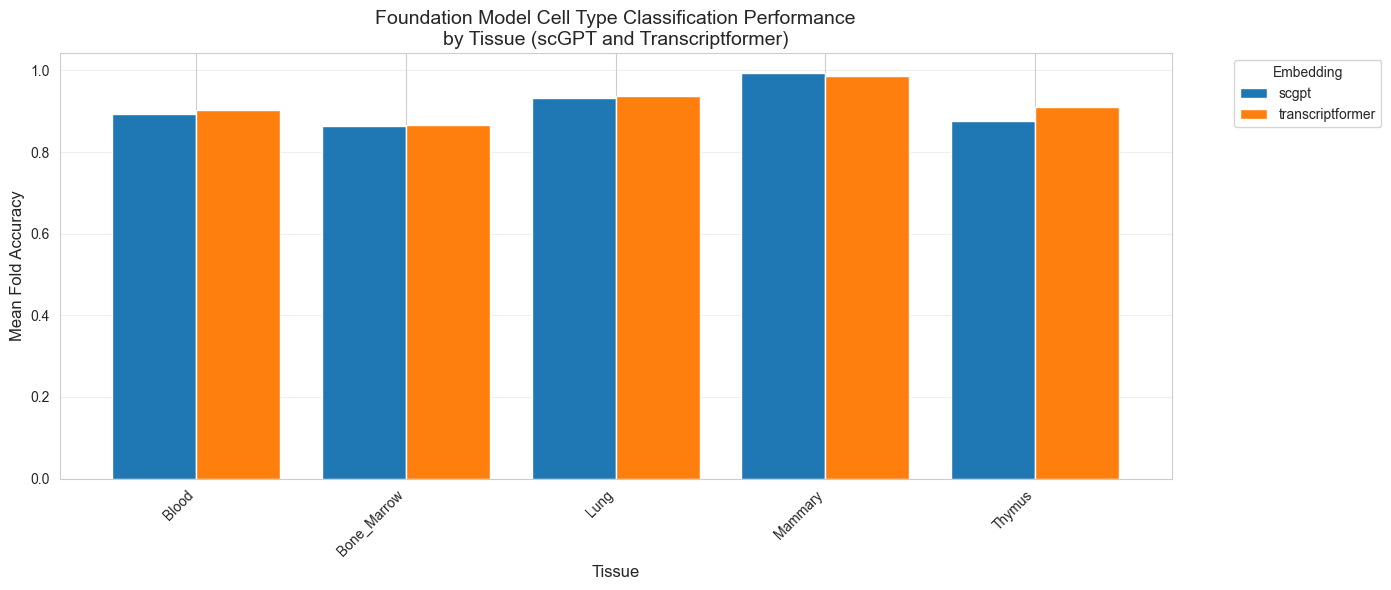

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Plot performance by tissue and embedding
if 'mean_fold_accuracy' in results_df.columns:
    successful_results = results_df[results_df['status'] == 'success']
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Create grouped bar plot
    pivot_data = successful_results.pivot_table(
        index='tissue',
        columns='embedding',
        values='mean_fold_accuracy'
    )
    
    pivot_data.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Tissue', fontsize=12)
    ax.set_ylabel('Mean Fold Accuracy', fontsize=12)
    ax.set_title('Foundation Model Cell Type Classification Performance\nby Tissue (scGPT and Transcriptformer)', fontsize=14)
    ax.legend(title='Embedding', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    fig_path = config.results_dir / 'cz_benchmarks_foundation_only_performance.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {fig_path}")
    
    plt.show()
else:
    print("No mean_fold_accuracy metric found in results")
    print("Cannot create visualization")

In [18]:
print("\n" + "="*80)
print("FOUNDATION MODEL EVALUATION COMPLETE")
print("="*80)
print(f"Results saved to: {config.results_dir}")
print(f"  - CSV: {results_file.name}")
if 'mean_fold_accuracy' in results_df.columns:
    print(f"  - Figure: cz_benchmarks_foundation_only_performance.png")
print("\nEvaluated scGPT and Transcriptformer alone for direct comparison!")


FOUNDATION MODEL EVALUATION COMPLETE
Results saved to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results
  - CSV: cz_benchmarks_foundation_only_results.csv
  - Figure: cz_benchmarks_foundation_only_performance.png

Evaluated scGPT and Transcriptformer alone for direct comparison!
